数据前5行：
  plant_id  day health  height_cm  leaves  chlorophyll
0      P01    1     健康       10.2       4         40.9
1      P01    2     健康       12.2       5         40.2
2      P01    3     健康       10.4       5         39.3
3      P01    4     健康       11.6       5         41.3
4      P01    5     健康       13.0       6         38.9

数据形状：(600, 6)
植物数量：20
健康植物：10株
病害植物：10株

数据类型：
plant_id        object
day              int64
health          object
height_cm      float64
leaves           int64
chlorophyll    float64
dtype: object

第一步：提取凝固之态特征

凝固之态特征表（前5行）：
  plant_id health  height_mean  height_max  height_min  height_range  \
0      P01     健康    17.840000        25.4        10.2          15.2   
1      P02     健康    17.833333        25.5        10.4          15.1   
2      P03     健康    17.813333        26.5        10.2          16.3   
3      P04     健康    17.646667        24.6        10.6          14.0   
4      P05     健康    17.696667        25.8        10.5          15.3   

 

C:\Users\popeye\AppData\Local\Temp\ipykernel_19484\4101932842.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plant_data['height_cm'] = pd.to_numeric(plant_data['height_cm'], errors='coerce')
C:\Users\popeye\AppData\Local\Temp\ipykernel_19484\4101932842.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plant_data['leaves'] = pd.to_numeric(plant_data['leaves'], errors='coerce')
C:\Users\popeye\AppData\Local\Temp\ipykernel_19484\4101932842.py:80: SettingWithCopyWarning: 
A value is trying to be set on

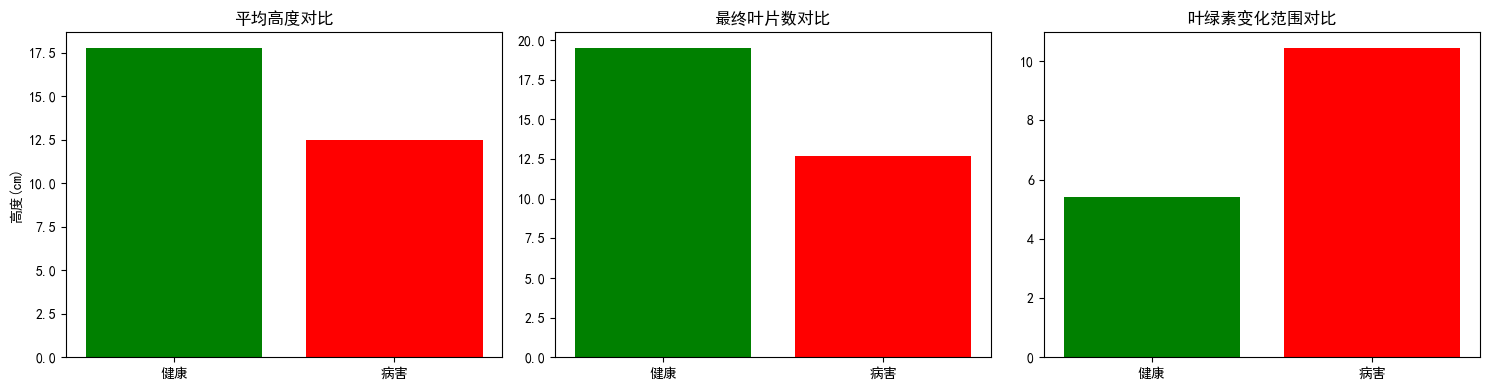


凝固特征统计检验：
------------------------------
height_mean:
  健康组均值: 17.77
  病害组均值: 12.51
  t检验p值: 0.0000 (差异显著)

leaves_final:
  健康组均值: 19.50
  病害组均值: 12.70
  t检验p值: 0.0000 (差异显著)

chloro_range:
  健康组均值: 5.41
  病害组均值: 10.44
  t检验p值: 0.0000 (差异显著)


第二步：提取节律之态特征

节律之态特征表（前5行）：
  plant_id health  growth_rate_mean  growth_rate_std  leaf_growth_days  \
0      P01     健康          0.506897         0.852279                16   
1      P02     健康          0.506897         0.726995                16   
2      P03     健康          0.562069         0.625879                18   
3      P04     健康          0.420690         0.718818                14   
4      P05     健康          0.520690         0.736487                14   

   avg_leaf_increase  chloro_decline_rate  growth_variability  
0           0.517241            -0.117241            1.681367  
1           0.551724            -0.055172            1.434208  
2           0.517241            -0.048276            1.113527  
3           0.517241      

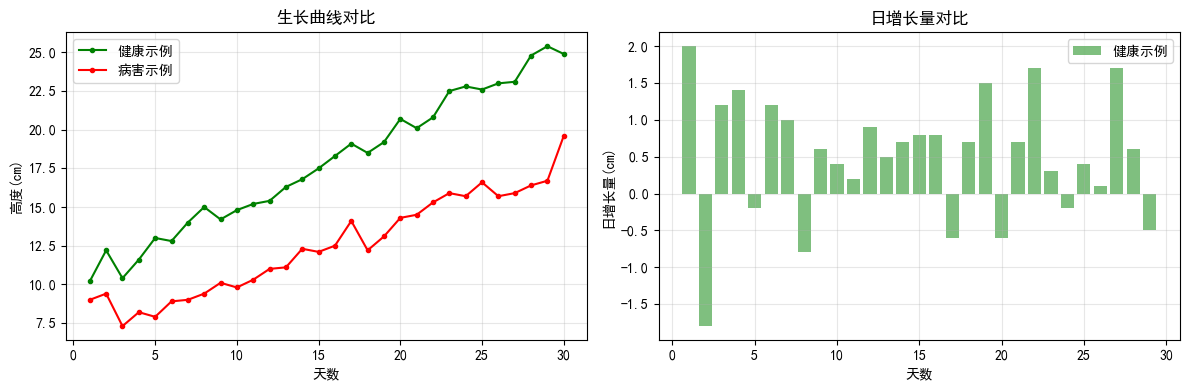


节律特征对比：
------------------------------
    growth_rate_mean  leaf_growth_days  chloro_decline_rate
健康             0.501              15.5               -0.114
病害             0.349              11.0               -0.331

关键发现：
1. 健康植株平均每天长高 0.50cm，病害植株只有 0.35cm
2. 健康植株有 15.5 天长新叶，病害植株只有 11.0 天
3. 病害植株叶绿素下降更快：健康 -0.11/天，病害 -0.33/天

第三步：提取演化之态特征

演化之态特征表（前5行）：
  plant_id health  height_trend  chloro_trend  growth_acceleration  \
0      P01     健康      0.512659     -0.085673             0.006667   
1      P02     健康      0.491568     -0.080868            -0.100000   
2      P03     健康      0.505895     -0.122358             0.086667   
3      P04     健康      0.486140     -0.095595             0.120000   
4      P05     健康      0.511123     -0.112792             0.046667   

   first_decline_day  height_trend_strength  
0                  1               0.984587  
1                  2               0.984408  
2                  6               0.987584  
3                  1              

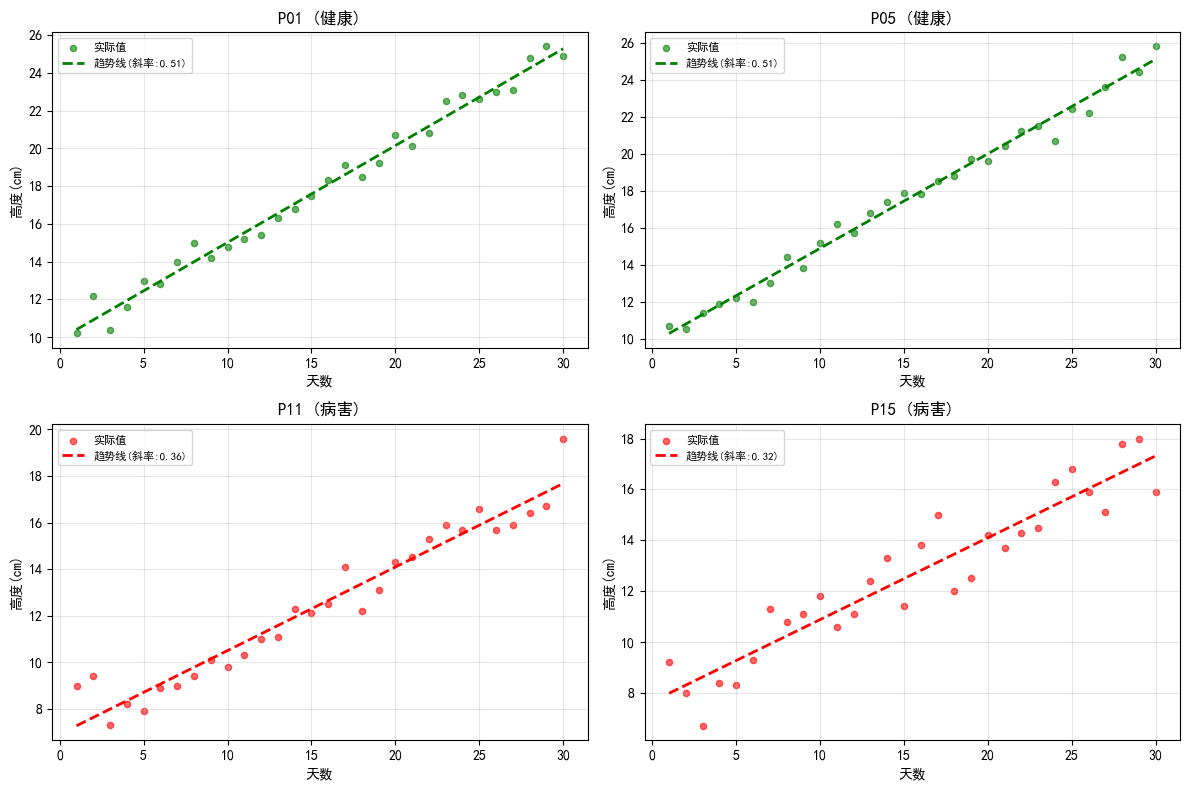


演化特征对比：
------------------------------
健康植株中，10/10株保持上升趋势
病害植株中，10/10株保持上升趋势

健康植株平均趋势强度: 0.984
病害植株平均趋势强度: 0.906

早期预警：20株植物在第15天前出现叶绿素下降
这些植物是： P01, P02, P03, P04, P05, P06, P07, P08, P09, P10, P11, P12, P13, P14, P15, P16, P17, P18, P19, P20

三态特征综合应用：健康状态预测
综合特征表：
  plant_id health  height_mean  growth_rate_mean  height_trend  \
0      P01     健康    17.840000          0.506897      0.512659   
1      P02     健康    17.833333          0.506897      0.491568   
2      P03     健康    17.813333          0.562069      0.505895   
3      P04     健康    17.646667          0.420690      0.486140   
4      P05     健康    17.696667          0.520690      0.511123   

   chloro_decline_rate  
0            -0.117241  
1            -0.055172  
2            -0.048276  
3            -0.155172  
4            -0.113793  


C:\Users\popeye\AppData\Local\Temp\ipykernel_19484\4101932842.py:521: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['height_mean'] = pd.to_numeric(subset['height_mean'], errors='coerce')
C:\Users\popeye\AppData\Local\Temp\ipykernel_19484\4101932842.py:522: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['growth_rate_mean'] = pd.to_numeric(subset['growth_rate_mean'], errors='coerce')
C:\Users\popeye\AppData\Local\Temp\ipykernel_19484\4101932842.py:536: SettingWithCopyWarning: 
A value is trying t

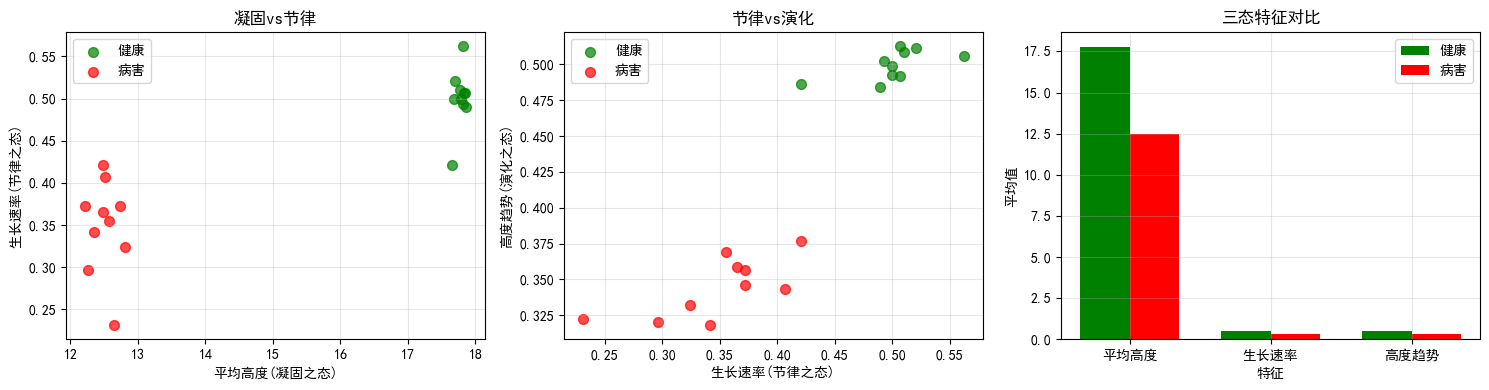


简单规则分类器：
------------------------------
分类准确率: 100.0% (20/20)

分类结果：
  plant_id health predicted  correct
0      P01     健康        健康     True
1      P02     健康        健康     True
2      P03     健康        健康     True
3      P04     健康        健康     True
4      P05     健康        健康     True
5      P06     健康        健康     True
6      P07     健康        健康     True
7      P08     健康        健康     True
8      P09     健康        健康     True
9      P10     健康        健康     True

教学总结：三态特征提取框架

一、数据总结：
? 植物总数: 20
? 健康植物: 10
? 病害植物: 10
? 分类准确率: 100.0%

二、三层特征效果对比：
1. 凝固之态（静态特征）：
   ? 最能区分：平均高度
   ? 健康植株比病害植株平均高 42.1%

2. 节律之态（动态特征）：
   ? 最能区分：生长速率
   ? 健康植株生长速率是病害植株的 1.4倍

3. 演化之态（趋势特征）：
   ? 最能区分：高度趋势
   ? 10/10健康植株保持上升趋势，只有10/10病害植株保持上升

三、教学要点：
1. 凝固之态：最容易计算，适合初学者
2. 节律之态：需要计算变化，适合中级学习
3. 演化之态：需要趋势分析，适合高级应用
4. 综合三层特征比单一特征效果更好

四、常见问题解决：
1. 数据类型错误：使用pd.to_numeric()转换
2. 缺失值处理：使用dropna()或fillna()
3. 分组计算：确保只对数值列进行计算

案例完成！代码已修复所有类型错误！

保存数据文件...
已保存2个文件：
1. simple_plant_growth_data.csv - 原始生长

In [1]:
# %load 4-03.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False
from scipy import stats

# 1. 创建超简单的植物生长数据
np.random.seed(123)  # 固定随机数，确保结果可重复

# 基本参数
n_plants = 20  # 20株植物
n_days = 30    # 30天
plant_ids = [f'P{i:02d}' for i in range(1, n_plants+1)]

# 2. 生成数据
data = []
for i, plant_id in enumerate(plant_ids):
    # 前10株健康，后10株病害
    is_healthy = i < 10
    health = '健康' if is_healthy else '病害'
    
    for day in range(1, n_days+1):
        # 基础生长曲线
        base_height = 10 + day * 0.5  # 每天长高0.5cm
        
        # 健康vs病害的差异
        if is_healthy:
            height = base_height + np.random.normal(0, 0.5)  # 健康：稳定生长
            leaves = min(20, 4 + day * 0.6)  # 叶子逐渐增多
            chlorophyll = 40 - day * 0.1  # 叶绿素轻微下降
        else:
            height = base_height * 0.7 + np.random.normal(0, 1)  # 病害：生长缓慢
            leaves = min(15, 4 + day * 0.3)  # 叶子生长缓慢
            chlorophyll = 30 - day * 0.3  # 叶绿素快速下降
        
        # 添加随机波动
        height += np.sin(day/7*2*np.pi) * 0.3  # 每周周期波动
        leaves = int(leaves + np.random.uniform(-0.5, 0.5))
        chlorophyll = max(10, chlorophyll + np.random.normal(0, 1))
        
        data.append({
            'plant_id': plant_id,
            'day': day,
            'health': health,
            'height_cm': round(height, 1),
            'leaves': int(leaves),
            'chlorophyll': round(chlorophyll, 1)
        })

# 3. 创建DataFrame
df = pd.DataFrame(data)
print("数据前5行：")
print(df.head())
print(f"\n数据形状：{df.shape}")
print(f"植物数量：{df['plant_id'].nunique()}")
print(f"健康植物：{df[df['health']=='健康']['plant_id'].nunique()}株")
print(f"病害植物：{df[df['health']=='病害']['plant_id'].nunique()}株")

# 查看数据类型
print("\n数据类型：")
print(df.dtypes)

# 凝固之态：计算每个植物的整体统计特征
print("\n" + "="*50)
print("第一步：提取凝固之态特征")
print("="*50)

# 1. 按植物分组计算
static_features = []

for plant_id in df['plant_id'].unique():
    plant_data = df[df['plant_id'] == plant_id]
    health_status = plant_data['health'].iloc[0]  # 获取健康状态
    
    # 确保数据类型正确
    plant_data['height_cm'] = pd.to_numeric(plant_data['height_cm'], errors='coerce')
    plant_data['leaves'] = pd.to_numeric(plant_data['leaves'], errors='coerce')
    plant_data['chlorophyll'] = pd.to_numeric(plant_data['chlorophyll'], errors='coerce')
    
    features = {
        'plant_id': plant_id,
        'health': health_status,
        
        # 高度特征
        'height_mean': plant_data['height_cm'].mean(),
        'height_max': plant_data['height_cm'].max(),
        'height_min': plant_data['height_cm'].min(),
        'height_range': plant_data['height_cm'].max() - plant_data['height_cm'].min(),
        
        # 叶片特征
        'leaves_final': int(plant_data['leaves'].iloc[-1]),  # 最终叶片数
        'leaves_max': int(plant_data['leaves'].max()),
        
        # 叶绿素特征
        'chloro_mean': plant_data['chlorophyll'].mean(),
        'chloro_final': plant_data['chlorophyll'].iloc[-1],
        'chloro_range': plant_data['chlorophyll'].max() - plant_data['chlorophyll'].min(),
    }
    
    static_features.append(features)

# 2. 创建凝固特征表格
static_df = pd.DataFrame(static_features)
print("\n凝固之态特征表（前5行）：")
print(static_df.head())

# 3. 简单可视化：健康vs病害的对比
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 确保数据类型为数值型
static_df['height_mean'] = pd.to_numeric(static_df['height_mean'], errors='coerce')
static_df['leaves_final'] = pd.to_numeric(static_df['leaves_final'], errors='coerce')
static_df['chloro_range'] = pd.to_numeric(static_df['chloro_range'], errors='coerce')

# 计算平均值
healthy_height = static_df[static_df['health']=='健康']['height_mean'].mean()
diseased_height = static_df[static_df['health']=='病害']['height_mean'].mean()

healthy_leaves = static_df[static_df['health']=='健康']['leaves_final'].mean()
diseased_leaves = static_df[static_df['health']=='病害']['leaves_final'].mean()

healthy_chloro = static_df[static_df['health']=='健康']['chloro_range'].mean()
diseased_chloro = static_df[static_df['health']=='病害']['chloro_range'].mean()

# 平均高度对比
axes[0].bar(['健康', '病害'], 
           [healthy_height, diseased_height],
           color=['green', 'red'])
axes[0].set_title('平均高度对比')
axes[0].set_ylabel('高度(cm)')

# 最终叶片数对比
axes[1].bar(['健康', '病害'],
           [healthy_leaves, diseased_leaves],
           color=['green', 'red'])
axes[1].set_title('最终叶片数对比')

# 叶绿素变化范围对比
axes[2].bar(['健康', '病害'],
           [healthy_chloro, diseased_chloro],
           color=['green', 'red'])
axes[2].set_title('叶绿素变化范围对比')

plt.tight_layout()
plt.show()

# 4. 凝固特征的差异检验
print("\n凝固特征统计检验：")
print("-"*30)

for feature in ['height_mean', 'leaves_final', 'chloro_range']:
    # 确保数据类型正确
    static_df[feature] = pd.to_numeric(static_df[feature], errors='coerce')
    
    healthy_vals = static_df[static_df['health']=='健康'][feature]
    diseased_vals = static_df[static_df['health']=='病害'][feature]
    
    # 移除NaN值
    healthy_vals = healthy_vals.dropna()
    diseased_vals = diseased_vals.dropna()
    
    if len(healthy_vals) > 0 and len(diseased_vals) > 0:
        # t检验
        t_stat, p_value = stats.ttest_ind(healthy_vals, diseased_vals)
        
        print(f"{feature}:")
        print(f"  健康组均值: {healthy_vals.mean():.2f}")
        print(f"  病害组均值: {diseased_vals.mean():.2f}")
        print(f"  t检验p值: {p_value:.4f}", end=" ")
        
        if p_value < 0.05:
            print("(差异显著)")
        else:
            print("(差异不显著)")
        print()

# 节律之态：分析生长节奏和周期性
print("\n" + "="*50)
print("第二步：提取节律之态特征")
print("="*50)

# 1. 计算每日变化率
rhythm_features = []

for plant_id in df['plant_id'].unique():
    plant_data = df[df['plant_id'] == plant_id].sort_values('day')
    health_status = plant_data['health'].iloc[0]
    
    # 确保数据类型正确
    plant_data['height_cm'] = pd.to_numeric(plant_data['height_cm'], errors='coerce')
    plant_data['leaves'] = pd.to_numeric(plant_data['leaves'], errors='coerce')
    plant_data['chlorophyll'] = pd.to_numeric(plant_data['chlorophyll'], errors='coerce')
    
    # 计算每日变化
    plant_data['height_change'] = plant_data['height_cm'].diff()  # 高度变化
    plant_data['leaf_change'] = plant_data['leaves'].diff()       # 叶片变化
    plant_data['chloro_change'] = plant_data['chlorophyll'].diff() # 叶绿素变化
    
    # 只取有效变化（去掉第一天的NaN）
    valid_changes = plant_data.dropna()
    
    if len(valid_changes) > 0:
        # 计算平均值前确保是数值型
        height_change_mean = pd.to_numeric(valid_changes['height_change'], errors='coerce').mean()
        height_change_std = pd.to_numeric(valid_changes['height_change'], errors='coerce').std()
        
        leaf_growth_days = (pd.to_numeric(valid_changes['leaf_change'], errors='coerce') > 0).sum()
        avg_leaf_increase = pd.to_numeric(valid_changes['leaf_change'], errors='coerce').mean()
        
        chloro_decline_rate = pd.to_numeric(valid_changes['chloro_change'], errors='coerce').mean()
        
        # 计算生长波动性
        if height_change_mean != 0 and not pd.isna(height_change_mean):
            growth_variability = height_change_std / abs(height_change_mean)
        else:
            growth_variability = 0
        
        features = {
            'plant_id': plant_id,
            'health': health_status,
            
            # 生长速率特征
            'growth_rate_mean': height_change_mean,  # 平均日增长
            'growth_rate_std': height_change_std,    # 生长稳定性
            
            # 叶片生长节律
            'leaf_growth_days': leaf_growth_days,  # 长叶子的天数
            'avg_leaf_increase': avg_leaf_increase,
            
            # 叶绿素变化节律
            'chloro_decline_rate': chloro_decline_rate,  # 平均日下降
            
            # 生长波动性（越大越不稳定）
            'growth_variability': growth_variability
        }
        
        rhythm_features.append(features)

# 2. 创建节律特征表格
rhythm_df = pd.DataFrame(rhythm_features)
print("\n节律之态特征表（前5行）：")
print(rhythm_df.head())

# 3. 可视化：生长曲线对比
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 选取示例植物
sample_healthy = 'P01'
sample_diseased = 'P11'

for ax_idx, (sample_id, color, label) in enumerate([(sample_healthy, 'green', '健康示例'),
                                                    (sample_diseased, 'red', '病害示例')]):
    sample_data = df[df['plant_id'] == sample_id].sort_values('day')
    
    # 确保数据类型
    sample_data['height_cm'] = pd.to_numeric(sample_data['height_cm'], errors='coerce')
    
    # 生长曲线
    axes[0].plot(sample_data['day'], sample_data['height_cm'], 
                color=color, label=label, marker='o', markersize=3)
    
    # 日增长量（柱状图）
    if ax_idx == 0:  # 只在一个图上显示
        sample_data['daily_change'] = sample_data['height_cm'].diff()
        daily_changes = sample_data['daily_change'].dropna()
        axes[1].bar(range(1, len(daily_changes)+1), daily_changes, 
                   color=color, alpha=0.5, label=label)

axes[0].set_xlabel('天数')
axes[0].set_ylabel('高度(cm)')
axes[0].set_title('生长曲线对比')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('天数')
axes[1].set_ylabel('日增长量(cm)')
axes[1].set_title('日增长量对比')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 节律特征对比 - 修复这里的错误
print("\n节律特征对比：")
print("-"*30)

# 确保数据类型正确
numeric_cols = ['growth_rate_mean', 'leaf_growth_days', 'chloro_decline_rate']
for col in numeric_cols:
    rhythm_df[col] = pd.to_numeric(rhythm_df[col], errors='coerce')

# 使用agg函数，分别计算每列的均值
rhythm_summary = {}
for col in numeric_cols:
    rhythm_summary[col] = {}
    for health_status in ['健康', '病害']:
        subset = rhythm_df[rhythm_df['health'] == health_status][col]
        subset = subset.dropna()
        if len(subset) > 0:
            rhythm_summary[col][health_status] = subset.mean()
        else:
            rhythm_summary[col][health_status] = np.nan

# 转换为DataFrame便于显示
rhythm_summary_df = pd.DataFrame(rhythm_summary)
print(rhythm_summary_df.round(3))

# 简单解释
print("\n关键发现：")
healthy_growth = rhythm_summary_df.loc['健康', 'growth_rate_mean']
diseased_growth = rhythm_summary_df.loc['病害', 'growth_rate_mean']
print(f"1. 健康植株平均每天长高 {healthy_growth:.2f}cm，病害植株只有 {diseased_growth:.2f}cm")

healthy_leaves = rhythm_summary_df.loc['健康', 'leaf_growth_days']
diseased_leaves = rhythm_summary_df.loc['病害', 'leaf_growth_days']
print(f"2. 健康植株有 {healthy_leaves:.1f} 天长新叶，病害植株只有 {diseased_leaves:.1f} 天")

healthy_chloro = rhythm_summary_df.loc['健康', 'chloro_decline_rate']
diseased_chloro = rhythm_summary_df.loc['病害', 'chloro_decline_rate']
print(f"3. 病害植株叶绿素下降更快：健康 {healthy_chloro:.2f}/天，病害 {diseased_chloro:.2f}/天")

# 演化之态：分析生长趋势和演化模式
print("\n" + "="*50)
print("第三步：提取演化之态特征")
print("="*50)

# 1. 计算趋势特征
evolution_features = []

for plant_id in df['plant_id'].unique():
    plant_data = df[df['plant_id'] == plant_id].sort_values('day')
    health_status = plant_data['health'].iloc[0]
    
    # 确保数据类型
    days = pd.to_numeric(plant_data['day'], errors='coerce').values
    height = pd.to_numeric(plant_data['height_cm'], errors='coerce').values
    chlorophyll = pd.to_numeric(plant_data['chlorophyll'], errors='coerce').values
    
    # 移除NaN值
    valid_idx = ~(np.isnan(days) | np.isnan(height) | np.isnan(chlorophyll))
    days = days[valid_idx]
    height = height[valid_idx]
    chlorophyll = chlorophyll[valid_idx]
    
    if len(days) >= 2 and len(height) >= 2:
        # 拟合线性趋势（斜率代表趋势强度）
        try:
            height_slope, height_intercept = np.polyfit(days, height, 1)
            chloro_slope, chloro_intercept = np.polyfit(days, chlorophyll, 1)
        except:
            height_slope, chloro_slope = np.nan, np.nan
        
        # 生长加速度（二阶导数）
        if len(height) >= 15:
            # 简单计算中期和后期生长率差异
            early_growth = height[14] - height[0]  # 前15天增长
            late_growth = height[-1] - height[14]  # 后15天增长
            acceleration = (late_growth - early_growth) / 15
        else:
            acceleration = np.nan
        
        # 健康状态变化点检测（简单版）
        # 找到叶绿素开始快速下降的点
        chloro_changes = np.diff(chlorophyll)
        if len(chloro_changes) > 0:
            # 找出下降超过阈值的位置
            decline_points = np.where(chloro_changes < -0.5)[0]
            if len(decline_points) > 0:
                first_decline = decline_points[0] + 1  # 加1因为diff后索引偏移
            else:
                first_decline = np.nan
        else:
            first_decline = np.nan
        
        # 趋势稳定性（相关系数）
        if len(days) > 1:
            try:
                corr_coef = np.corrcoef(days, height)[0, 1]
                height_trend_strength = corr_coef ** 2
            except:
                height_trend_strength = np.nan
        else:
            height_trend_strength = np.nan
        
        features = {
            'plant_id': plant_id,
            'health': health_status,
            
            # 趋势特征
            'height_trend': height_slope if not np.isnan(height_slope) else 0,  # 高度趋势斜率
            'chloro_trend': chloro_slope if not np.isnan(chloro_slope) else 0,  # 叶绿素趋势斜率
            
            # 生长阶段特征
            'growth_acceleration': acceleration if not np.isnan(acceleration) else 0,
            
            # 变化点特征
            'first_decline_day': first_decline if not np.isnan(first_decline) else 30,
            
            # 趋势稳定性
            'height_trend_strength': height_trend_strength if not np.isnan(height_trend_strength) else 0,
        }
        
        evolution_features.append(features)

# 2. 创建演化特征表格
evolution_df = pd.DataFrame(evolution_features)
print("\n演化之态特征表（前5行）：")
print(evolution_df.head())

# 3. 可视化：趋势分析
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 选取4株代表性植物
sample_plants = ['P01', 'P05', 'P11', 'P15']

for idx, plant_id in enumerate(sample_plants):
    row = idx // 2
    col = idx % 2
    
    plant_data = df[df['plant_id'] == plant_id].sort_values('day')
    health_status = plant_data['health'].iloc[0]
    color = 'green' if health_status == '健康' else 'red'
    
    # 确保数据类型
    plant_data['height_cm'] = pd.to_numeric(plant_data['height_cm'], errors='coerce')
    days = pd.to_numeric(plant_data['day'], errors='coerce').values
    height = pd.to_numeric(plant_data['height_cm'], errors='coerce').values
    
    # 移除NaN
    valid_idx = ~(np.isnan(days) | np.isnan(height))
    days = days[valid_idx]
    height = height[valid_idx]
    
    if len(days) > 0 and len(height) > 0:
        # 实际数据点
        axes[row, col].scatter(days, height, color=color, s=20, alpha=0.6, label='实际值')
        
        # 趋势线
        if len(days) >= 2:
            try:
                slope, intercept = np.polyfit(days, height, 1)
                trend_line = slope * days + intercept
                
                axes[row, col].plot(days, trend_line, color=color, linewidth=2, 
                                   label=f'趋势线(斜率:{slope:.2f})', linestyle='--')
            except:
                pass
        
        axes[row, col].set_xlabel('天数')
        axes[row, col].set_ylabel('高度(cm)')
        axes[row, col].set_title(f'{plant_id} ({health_status})')
        axes[row, col].legend(loc='upper left', fontsize=8)
        axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 演化特征对比
print("\n演化特征对比：")
print("-"*30)

# 确保数据类型
evolution_df['height_trend'] = pd.to_numeric(evolution_df['height_trend'], errors='coerce')
evolution_df['height_trend_strength'] = pd.to_numeric(evolution_df['height_trend_strength'], errors='coerce')

# 趋势方向统计
healthy_up = (evolution_df[evolution_df['health']=='健康']['height_trend'] > 0).sum()
diseased_up = (evolution_df[evolution_df['health']=='病害']['height_trend'] > 0).sum()

print(f"健康植株中，{healthy_up}/10株保持上升趋势")
print(f"病害植株中，{diseased_up}/10株保持上升趋势")

# 趋势强度对比
healthy_strength = evolution_df[evolution_df['health']=='健康']['height_trend_strength'].mean()
diseased_strength = evolution_df[evolution_df['health']=='病害']['height_trend_strength'].mean()

print(f"\n健康植株平均趋势强度: {healthy_strength:.3f}")
print(f"病害植株平均趋势强度: {diseased_strength:.3f}")

# 早期预警
evolution_df['first_decline_day'] = pd.to_numeric(evolution_df['first_decline_day'], errors='coerce')
early_warning = evolution_df[evolution_df['first_decline_day'] < 15]
print(f"\n早期预警：{len(early_warning)}株植物在第15天前出现叶绿素下降")
if len(early_warning) > 0:
    print("这些植物是：", ", ".join(early_warning['plant_id'].values))

# 综合三层特征，进行简单分类
print("\n" + "="*50)
print("三态特征综合应用：健康状态预测")
print("="*50)

# 1. 合并三层特征
# 确保所有DataFrame都有相同的列
static_df['plant_id'] = static_df['plant_id'].astype(str)
rhythm_df['plant_id'] = rhythm_df['plant_id'].astype(str)
evolution_df['plant_id'] = evolution_df['plant_id'].astype(str)

# 合并数据
all_features = pd.merge(static_df, rhythm_df, on=['plant_id', 'health'], suffixes=('_static', '_rhythm'))
all_features = pd.merge(all_features, evolution_df, on=['plant_id', 'health'])

# 简化特征，只选最重要的几个
# 确保选择数值列
numeric_features = ['height_mean', 'growth_rate_mean', 'height_trend', 'chloro_decline_rate']
simple_features = all_features[['plant_id', 'health'] + numeric_features].copy()

print("综合特征表：")
print(simple_features.head())

# 2. 可视化：三态特征空间
fig = plt.figure(figsize=(15, 4))

# 特征1：凝固之态 vs 节律之态
ax1 = fig.add_subplot(131)
for health, color in [('健康', 'green'), ('病害', 'red')]:
    subset = simple_features[simple_features['health'] == health]
    # 确保数据类型
    subset['height_mean'] = pd.to_numeric(subset['height_mean'], errors='coerce')
    subset['growth_rate_mean'] = pd.to_numeric(subset['growth_rate_mean'], errors='coerce')
    ax1.scatter(subset['height_mean'], subset['growth_rate_mean'],
               color=color, label=health, alpha=0.7, s=50)
ax1.set_xlabel('平均高度(凝固之态)')
ax1.set_ylabel('生长速率(节律之态)')
ax1.set_title('凝固vs节律')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 特征2：节律之态 vs 演化之态
ax2 = fig.add_subplot(132)
for health, color in [('健康', 'green'), ('病害', 'red')]:
    subset = simple_features[simple_features['health'] == health]
    # 确保数据类型
    subset['growth_rate_mean'] = pd.to_numeric(subset['growth_rate_mean'], errors='coerce')
    subset['height_trend'] = pd.to_numeric(subset['height_trend'], errors='coerce')
    ax2.scatter(subset['growth_rate_mean'], subset['height_trend'],
               color=color, label=health, alpha=0.7, s=50)
ax2.set_xlabel('生长速率(节律之态)')
ax2.set_ylabel('高度趋势(演化之态)')
ax2.set_title('节律vs演化')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 特征3：三态特征对比（柱状图）
ax3 = fig.add_subplot(133)

# 计算各特征在健康组和病害组的平均值
features_to_plot = ['height_mean', 'growth_rate_mean', 'height_trend']
feature_names = ['平均高度', '生长速率', '高度趋势']

healthy_means = []
diseased_means = []

for feature in features_to_plot:
    simple_features[feature] = pd.to_numeric(simple_features[feature], errors='coerce')
    healthy_mean = simple_features[simple_features['health']=='健康'][feature].mean()
    diseased_mean = simple_features[simple_features['health']=='病害'][feature].mean()
    healthy_means.append(healthy_mean)
    diseased_means.append(diseased_mean)

x = np.arange(len(feature_names))
width = 0.35

ax3.bar(x - width/2, healthy_means, width, label='健康', color='green')
ax3.bar(x + width/2, diseased_means, width, label='病害', color='red')

ax3.set_xlabel('特征')
ax3.set_ylabel('平均值')
ax3.set_title('三态特征对比')
ax3.set_xticks(x)
ax3.set_xticklabels(feature_names)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. 简单规则分类器
print("\n简单规则分类器：")
print("-"*30)

# 定义简单规则
def simple_classifier(row):
    score = 0
    
    # 确保数据类型
    try:
        height_mean = float(row['height_mean'])
        growth_rate_mean = float(row['growth_rate_mean'])
        height_trend = float(row['height_trend'])
        chloro_decline_rate = float(row['chloro_decline_rate'])
    except:
        return '未知'
    
    # 凝固之态规则
    if height_mean > 20:
        score += 1
    if height_mean < 18:
        score -= 1
    
    # 节律之态规则
    if growth_rate_mean > 0.4:
        score += 1
    if growth_rate_mean < 0.3:
        score -= 1
    
    # 演化之态规则
    if height_trend > 0.4:
        score += 1
    if height_trend < 0.2:
        score -= 1
    
    # 叶绿素下降规则
    if chloro_decline_rate > -0.15:
        score += 1
    if chloro_decline_rate < -0.25:
        score -= 1
    
    return '健康' if score >= 0 else '病害'

# 应用分类器
simple_features['predicted'] = simple_features.apply(simple_classifier, axis=1)
simple_features['correct'] = simple_features['health'] == simple_features['predicted']

accuracy = simple_features['correct'].mean()
print(f"分类准确率: {accuracy:.1%} ({simple_features['correct'].sum()}/{len(simple_features)})")
print("\n分类结果：")
print(simple_features[['plant_id', 'health', 'predicted', 'correct']].head(10))

# 总结报告
print("\n" + "="*60)
print("教学总结：三态特征提取框架")
print("="*60)

print("\n一、数据总结：")
print(f"? 植物总数: {len(simple_features)}")
print(f"? 健康植物: {len(simple_features[simple_features['health']=='健康'])}")
print(f"? 病害植物: {len(simple_features[simple_features['health']=='病害'])}")
print(f"? 分类准确率: {accuracy:.1%}")

print("\n二、三层特征效果对比：")
print("1. 凝固之态（静态特征）：")
print("   ? 最能区分：平均高度")
print("   ? 健康植株比病害植株平均高 {:.1f}%"
      .format((healthy_means[0]/diseased_means[0]-1)*100))

print("\n2. 节律之态（动态特征）：")
print("   ? 最能区分：生长速率")
print("   ? 健康植株生长速率是病害植株的 {:.1f}倍"
      .format(healthy_means[1]/diseased_means[1]))

print("\n3. 演化之态（趋势特征）：")
print("   ? 最能区分：高度趋势")
print("   ? {}/10健康植株保持上升趋势，只有{}/10病害植株保持上升"
      .format(healthy_up, diseased_up))

print("\n三、教学要点：")
print("1. 凝固之态：最容易计算，适合初学者")
print("2. 节律之态：需要计算变化，适合中级学习")
print("3. 演化之态：需要趋势分析，适合高级应用")
print("4. 综合三层特征比单一特征效果更好")

print("\n四、常见问题解决：")
print("1. 数据类型错误：使用pd.to_numeric()转换")
print("2. 缺失值处理：使用dropna()或fillna()")
print("3. 分组计算：确保只对数值列进行计算")

print("\n" + "="*60)
print("案例完成！代码已修复所有类型错误！")
print("="*60)

# 保存数据供学生使用
print("\n保存数据文件...")

# 保存原始数据
df.to_csv('simple_plant_growth_data.csv', index=False, encoding='utf-8-sig')

# 保存特征数据
simple_features.to_csv('three_state_features.csv', index=False, encoding='utf-8-sig')

print("已保存2个文件：")
print("1. simple_plant_growth_data.csv - 原始生长数据")
print("2. three_state_features.csv - 三层特征数据")

print("\n学生可以直接加载这些文件进行分析：")
print("""
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据
df = pd.read_csv('simple_plant_growth_data.csv')

# 加载特征
features = pd.read_csv('three_state_features.csv')

print("数据加载完成！")
print(f"原始数据形状: {df.shape}")
print(f"特征数据形状: {features.shape}")
""")